### Step 1: Load the Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

### Step 2: Generate the Dataset & Perform Initial EDA

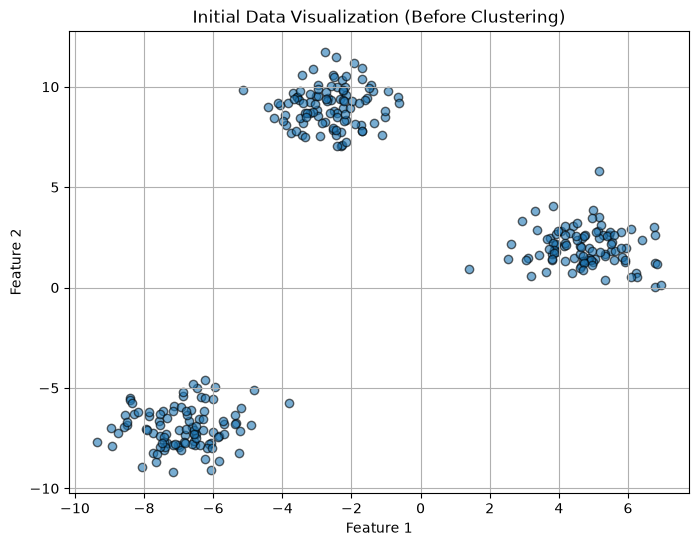

In [2]:
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Convert to DataFrame
data = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

# Initial EDA: Scatter plot of raw data
plt.figure(figsize=(8, 6))
plt.scatter(data['Feature1'], data['Feature2'], alpha=0.6, edgecolors='k')
plt.title('Initial Data Visualization (Before Clustering)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

### Step 3: Preprocess the Data

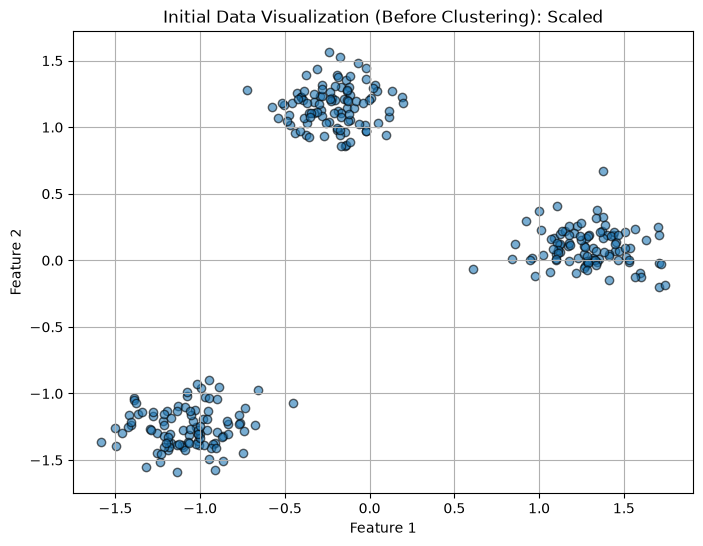

In [3]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

plt.figure(figsize=(8, 6))
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], alpha=0.6, edgecolors='k')
plt.title('Initial Data Visualization (Before Clustering): Scaled')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

### Step 4: Select the Number of Components (Clusters, K)

c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL,

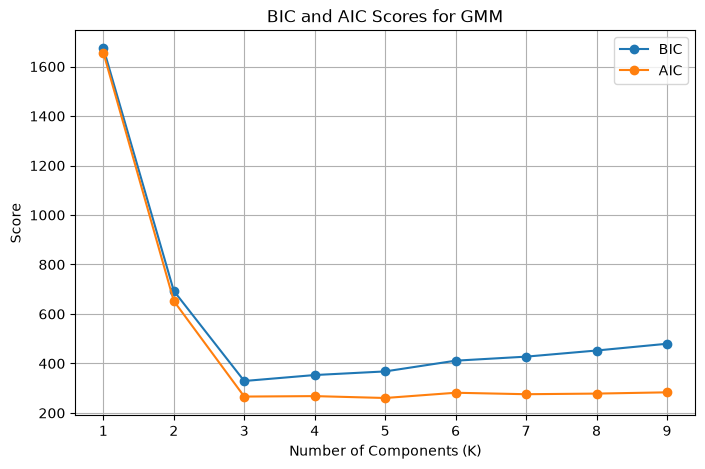

In [4]:
bic_scores = []
aic_scores = []
k_values = range(1, 10)

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm.fit(data_scaled)
    bic_scores.append(gmm.bic(data_scaled))
    aic_scores.append(gmm.aic(data_scaled))

# Plot BIC and AIC to find optimal K
plt.figure(figsize=(8, 5))
plt.plot(k_values, bic_scores, marker='o', linestyle='-', label='BIC')
plt.plot(k_values, aic_scores, marker='o', linestyle='-', label='AIC')
plt.xlabel('Number of Components (K)')
plt.ylabel('Score')
plt.legend()
plt.title('BIC and AIC Scores for GMM')
plt.grid(True)
plt.show()

### Step 5: Apply the Expectation-Maximization(E-M) Algorithm

In [5]:
optimal_k = 3
gmm = GaussianMixture(n_components=optimal_k, random_state=42, n_init=10)
gmm.fit(data_scaled)

# Predict cluster propabilities
probs = gmm.predict_proba(data_scaled)

# Assign clusters based on the highest probability
clusters_assignments = gmm.predict(data_scaled)

c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\25473\anaconda3\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning:

### Step 6: Identify Anomalies Using Probability Scores

In [6]:
# Compute minimum probability per point
min_prob = np.min(probs, axis=1)

# Define anomaly threshold (5th percentile)
threshold = np.percentile(min_prob, 5)

# Identify anomalies
anomalies = data[min_prob < threshold]

### Step 7: Visualize the Clusters and Anomalies

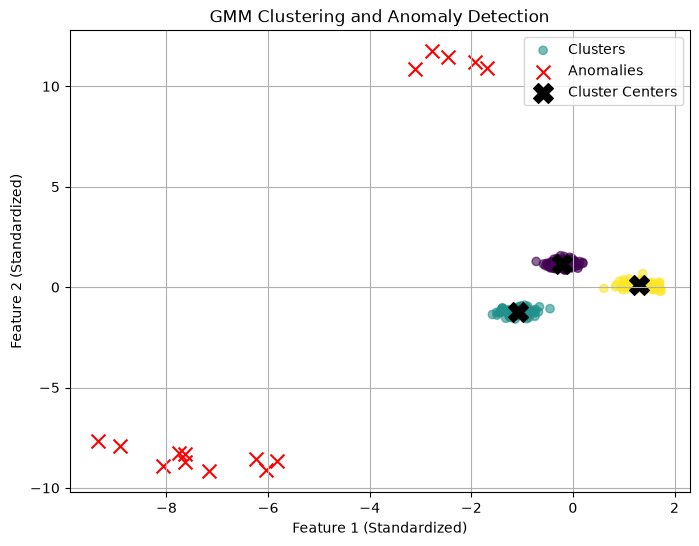

In [8]:
plt.figure(figsize=(8, 6))

# Scatter plot of all data points
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=clusters_assignments, cmap='viridis', alpha=0.6, label="Clusters")

# Highlight anomalies
plt.scatter(anomalies['Feature1'], anomalies['Feature2'], color='red', marker='x', s=100, label="Anomalies")

# Plot cluster centers
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], s=200, c='black', marker='X', label="Cluster Centers")

plt.title('GMM Clustering and Anomaly Detection')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.grid(True)
plt.show()